In [44]:
import numpy as np
import math
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.layers as tfl
import scipy
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
np.random.seed(1)

In [45]:
def load_dataset():
    train_dataset=h5py.File("/home/dikshant/projects/ml-fundamentals-pytorch/Dataset/train_signs.h5",'r')
    train_X = np.array(train_dataset["train_set_x"][:])
    train_y = np.array(train_dataset["train_set_y"][:])

    test_dataset = h5py.File("/home/dikshant/projects/ml-fundamentals-pytorch/Dataset/test_signs.h5","r")
    test_X=np.array(test_dataset["test_set_x"][:])
    test_y = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_y = train_y.reshape((1,train_y.shape[0]))
    test_y=test_y.reshape((1,test_y.shape[0]))

    return train_X, train_y, test_X, test_y, classes
    

In [46]:
train_X,train_y,test_X,test_y,classes = load_dataset()
train_X.shape, train_y.shape, test_X.shape, test_y.shape, classes.shape

((1080, 64, 64, 3), (1, 1080), (120, 64, 64, 3), (1, 120), (6,))

In [47]:
train_X_norm,test_X_norm = train_X/255.0,test_X/255.0
train_y,test_y=train_y.T,test_y.T

X_train, X_val, y_train, y_val = train_test_split(
    train_X_norm, 
    train_y, 
    test_size=0.20,      # 20% of the data goes to validation
    random_state=42,     # Ensures you get the exact same split every time you run the code
    stratify=train_y     # VERY IMPORTANT: Ensures the ratio of all classes stays the same in all sets
)

In [48]:
print("Number of training examples: ",X_train.shape[0])
print("Number of validation examples: ",X_val.shape[0])
print("Number of test examples: ", test_X_norm.shape[0])
print("train_X_norm shape: ", X_train.shape)
print("Val_X_norm shape: ", X_val.shape)
print("test_X_norm shape: ", test_X_norm.shape)
print("Number of Classes: ", classes[0])
print("y_train shape: ", y_train.shape)
print("y_val shape: ", y_val.shape)
print("test_y shape: ", test_y.shape)

Number of training examples:  864
Number of validation examples:  216
Number of test examples:  120
train_X_norm shape:  (864, 64, 64, 3)
Val_X_norm shape:  (216, 64, 64, 3)
test_X_norm shape:  (120, 64, 64, 3)
Number of Classes:  0
y_train shape:  (864, 1)
y_val shape:  (216, 1)
test_y shape:  (120, 1)


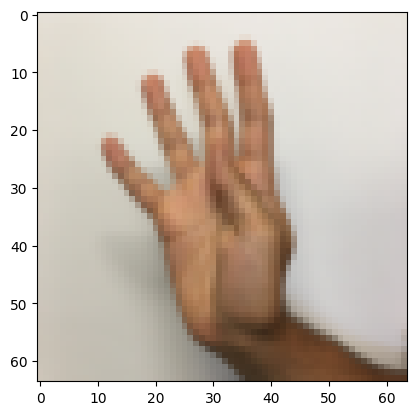

In [49]:
index = 130
plt.imshow(train_X[index]) #display sample training image

plt.show()


In [50]:
# Model layers architecture
## Augmentation layers , randomflip,randomrotation,randomzoom
## CONV2D: 8 filters 4x4, stride of 1, padding 'SAME'
# Z1 = None
## RELU
# A1 = None
## MAXPOOL: window 8x8, stride 8, padding 'SAME'
# P1 = None
## CONV2D: 16 filters 2x2, stride 1, padding 'SAME'
# Z2 = None
## RELU
# A2 = None
## MAXPOOL: window 4x4, stride 4, padding 'SAME'
# P2 = None
## FLATTEN
# F = None
## Dense layer
## 6 neurons in output layer. Hint: one of the arguments should be "activation='softmax'" 
# outputs = None

def SignClassifier(input_shape):
    input_img = tf.keras.Input(shape=input_shape)

    aug1=tfl.RandomFlip("horizontal")(input_img)
    aug2=tfl.RandomRotation(0.1)(aug1)
    aug3=tfl.RandomZoom(0.1)(aug2)
    
    Z1=tfl.Conv2D(filters=8,kernel_size=(4,4),strides=(1,1),padding='same')(aug3)
    A1= tfl.ReLU()(Z1)
    P1=tfl.MaxPool2D(pool_size=(8,8),strides=(8,8),padding='same')(A1)
    Z2=tfl.Conv2D(filters=16,kernel_size=(2,2),strides=(1,1),padding='same')(P1)
    A2=tfl.ReLU()(Z2)
    P2=tfl.MaxPool2D(pool_size=(4,4),strides=(4,4),padding='same')(A2)
    F=tfl.Flatten()(P2)
    outputs=tfl.Dense(units=6,activation='softmax')(F)
    # YOUR CODE ENDS HERE
    model = tf.keras.Model(inputs=input_img, outputs=outputs)
    return model

In [51]:
sign_classifier = SignClassifier((64, 64, 3))
sign_classifier.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
sign_classifier.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 8)      │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310 (5.12 KB)

 Trainable params: 1,310 (5.12 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
history = sign_classifier.fit(X_train, 
                                   y_train, 
                                   epochs=500, 
                                   batch_size=16, 
                                   validation_data=(X_val, y_val),
                                   # callbacks=[early_stop, reduce_lr]
                                  )

Epoch 1/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1794 - loss: 1.7953 - val_accuracy: 0.1759 - val_loss: 1.7824
Epoch 2/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1759 - loss: 1.7849 - val_accuracy: 0.2176 - val_loss: 1.7762
Epoch 3/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1991 - loss: 1.7787 - val_accuracy: 0.2639 - val_loss: 1.7650
Epoch 4/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2141 - loss: 1.7644 - val_accuracy: 0.2639 - val_loss: 1.7375
Epoch 5/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2569 - loss: 1.7423 - val_accuracy: 0.3009 - val_loss: 1.7117
Epoch 6/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3009 - loss: 1.7086 - val_accuracy: 0.3565 - val_loss: 1.6659
Epoch 7/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3264 - loss: 1.6607 - val_accuracy: 0.3843 - val_loss: 1.6002
Epoch 8/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3507 - loss: 1.6228 - val_accuracy: 0.3

In [53]:
sign_classifier.evaluate(test_X_norm,test_y)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9250 - loss: 0.2652


[0.2651859521865845, 0.925000011920929]

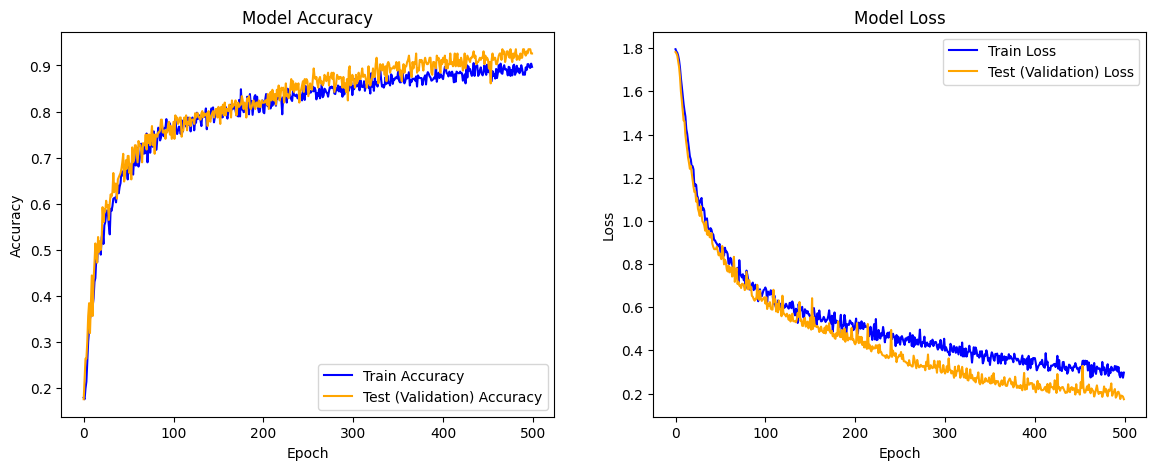

In [54]:
# 2. Plot the loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Test (Validation) Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Test (Validation) Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()